# 01: Returns, vol, fat tails

First pass over the data, just building intuition before doing anything fancy. Three questions to start with:

- What does the price history actually look like across these coins?
- Are daily returns roughly normal, or are the tails as bad as people say?
- Does volatility cluster? Do calm days tend to follow calm days?

These matter a lot for the later modeling choices. Fat tails plus vol clustering means Sharpe overstates the picture, normal-distribution VaR is fiction, and ARIMA-style models leave money on the table.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import utils as U

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('deep')

In [2]:
prices = U.load_panel()
print(prices.shape)
prices.tail(3)

(4266, 11)


,Bitcoin,Ethereum,BinanceCoin,Cardano,Solana,XRP,Polkadot,Dogecoin,Litecoin,ChainLink,Tether
Date,,,,,,,,,,,
2026-05-20,77457.773438,2126.983398,648.819275,0.249001,86.041939,1.365368,1.247423,0.103574,53.906731,9.621927,0.998998
2026-05-21,77539.171875,2131.410645,657.349854,0.250257,87.156204,1.372087,1.287756,0.105494,54.131657,9.740580,0.999033
2026-05-22,75464.539062,2062.669922,649.500000,0.242100,84.230003,1.333200,1.254000,0.102100,52.500000,9.401000,0.998860


### Coverage check

These coins all launched at different times. Solana didn't exist for the first half of Bitcoin's history, for example. We need to know where each series starts before doing any cross-sectional work, otherwise we'd be comparing apples to oranges.

In [3]:
coverage = pd.DataFrame({
    'first': prices.apply(lambda s: s.first_valid_index()),
    'last':  prices.apply(lambda s: s.last_valid_index()),
    'days':  prices.count(),
    'missing_pct': prices.isna().mean().round(3),
})
coverage.sort_values('first')

,first,last,days,missing_pct
Bitcoin,2014-09-17,2026-05-22,4266,0.000
Litecoin,2014-09-17,2026-05-22,4266,0.000
Ethereum,2017-11-09,2026-05-22,3117,0.269
BinanceCoin,2017-11-09,2026-05-22,3117,0.269
Cardano,2017-11-09,2026-05-22,3117,0.269
XRP,2017-11-09,2026-05-22,3117,0.269
Dogecoin,2017-11-09,2026-05-22,3117,0.269
ChainLink,2017-11-09,2026-05-22,3117,0.269
Tether,2017-11-09,2026-05-22,3117,0.269
Solana,2020-04-10,2026-05-22,2234,0.476


Most coins have a clean run from when they launched. For the cross-asset correlation work later, I'll restrict to dates where every coin in the panel has data.

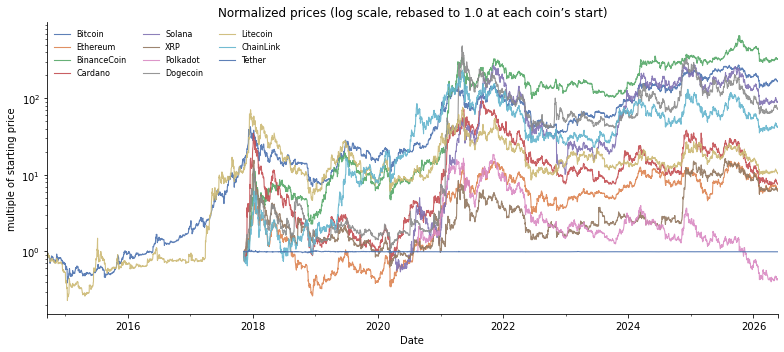

In [4]:
# Log scale because BTC went from $100 to $60k. Linear charts are useless here.
fig, ax = plt.subplots(figsize=(11, 5))
(prices / prices.bfill().iloc[0]).plot(ax=ax, logy=True, lw=1.1, alpha=0.9)
ax.set_title('Normalized prices (log scale, rebased to 1.0 at each coin\u2019s start)')
ax.set_ylabel('multiple of starting price')
ax.legend(loc='upper left', ncol=3, fontsize=8, frameon=False)
plt.tight_layout()

## Returns

Switching to log returns. They're additive across time and slightly better-behaved than simple returns for what we're doing.

In [5]:
rets = U.log_returns(prices)
rets.describe().T[['mean', 'std', 'min', 'max']].round(4)

,mean,std,min,max
Bitcoin,0.0012,0.0352,-0.4647,0.2251
Ethereum,0.0006,0.0451,-0.5507,0.2347
BinanceCoin,0.0019,0.0486,-0.5431,0.5292
Cardano,0.0006,0.0591,-0.5036,0.8615
Solana,0.0020,0.0626,-0.5496,0.3872
XRP,0.0006,0.0560,-0.5505,0.6069
Polkadot,-0.0004,0.0532,-0.4770,0.4446
Dogecoin,0.0014,0.0671,-0.5151,1.5163
Litecoin,0.0005,0.0511,-0.5146,0.5114
ChainLink,0.0012,0.0614,-0.6146,0.4806


Tether's std is about two orders of magnitude smaller than the rest. That's what a stablecoin should look like, and a useful sanity check that the data is what it claims to be.

In [6]:
# How fat are the tails?
moments = pd.DataFrame({
    'skew':     rets.skew(),
    'kurtosis': rets.kurt(),       # Fisher kurtosis; Normal is 0
    'min_day':  rets.min(),
    'max_day':  rets.max(),
}).round(3)
moments.sort_values('kurtosis', ascending=False)

,skew,kurtosis,min_day,max_day
Dogecoin,4.601,95.476,-0.515,1.516
Tether,0.912,77.260,-0.053,0.057
Cardano,1.970,27.720,-0.504,0.862
XRP,1.121,20.550,-0.551,0.607
BinanceCoin,0.435,20.117,-0.543,0.529
Litecoin,0.067,13.593,-0.515,0.511
Bitcoin,-0.709,11.828,-0.465,0.225
Ethereum,-0.771,10.636,-0.551,0.235
Polkadot,0.233,9.613,-0.477,0.445
ChainLink,-0.025,8.371,-0.615,0.481


Kurtosis in double digits is not subtle. S&P 500 daily returns sit around 5 to 10 depending on the window. The worst single day for several of these coins is a 30% drop in 24 hours. Definitely not a Gaussian distribution.

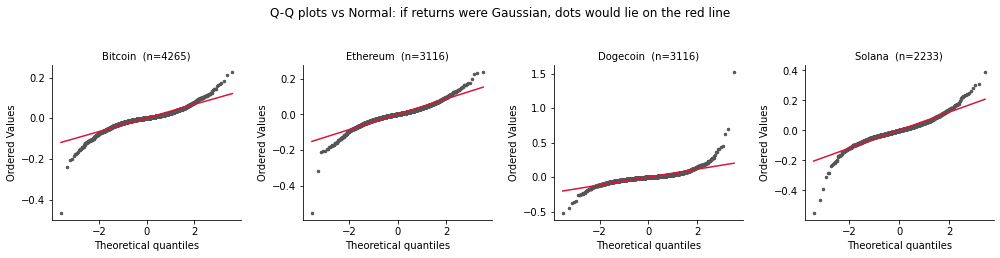

In [7]:
# QQ plot vs. normal for a few representative coins.
coins_to_show = ['Bitcoin', 'Ethereum', 'Dogecoin', 'Solana']
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, c in zip(axes, coins_to_show):
    if c in rets.columns:
        x = rets[c].dropna()
        stats.probplot(x, dist='norm', plot=ax)
        ax.set_title(f'{c}  (n={len(x)})', fontsize=10)
        ax.get_lines()[0].set_markersize(2.5)
        ax.get_lines()[0].set_color('#555')
        ax.get_lines()[1].set_color('crimson')
plt.suptitle('Q-Q plots vs Normal: if returns were Gaussian, dots would lie on the red line', y=1.04)
plt.tight_layout()

The lift-off in the tails is fat-tailedness in practice. The extreme observations sit way further from the mean than a normal distribution would ever produce. Anything that assumes normality is going to underprice risk.

## Volatility: does it cluster?

If today's vol predicts tomorrow's vol then "calm" and "stressed" regimes are a real thing rather than a story we tell after the fact. Easiest check is the autocorrelation of squared returns, which is a rough proxy for volatility.

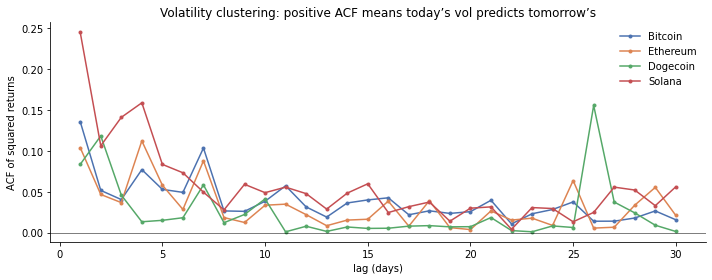

In [8]:
# Autocorrelation of squared returns. If this is zero we have no clustering;
# if it's positive and decays slowly, we have clustering.
from statsmodels.tsa.stattools import acf

lag = 30
acf_squared = {c: acf((rets[c].dropna()) ** 2, nlags=lag, fft=True)[1:]
               for c in coins_to_show if c in rets.columns}

fig, ax = plt.subplots(figsize=(10, 4))
for c, a in acf_squared.items():
    ax.plot(range(1, lag + 1), a, marker='.', label=c)
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('lag (days)')
ax.set_ylabel('ACF of squared returns')
ax.set_title('Volatility clustering: positive ACF means today\u2019s vol predicts tomorrow\u2019s')
ax.legend(frameon=False)
plt.tight_layout()

Strong positive autocorrelation that decays slowly out to 30 days. Vol clustering is real here. So vol-targeting strategies and GARCH-style models have something to work with. Constant-vol assumptions don't.

## Rolling 30-day annualized vol

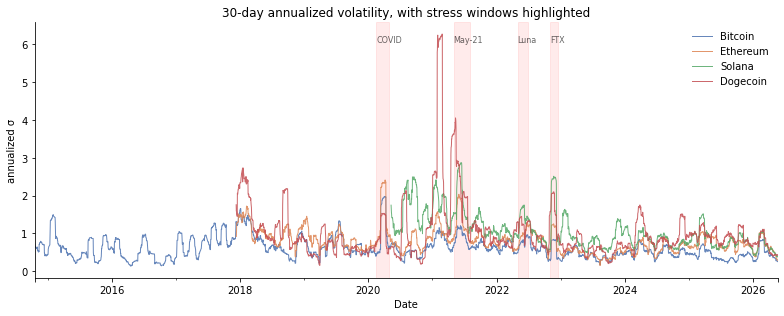

In [9]:
vol = U.rolling_vol(rets, window=30)

fig, ax = plt.subplots(figsize=(11, 4.5))
for c in ['Bitcoin', 'Ethereum', 'Solana', 'Dogecoin']:
    if c in vol.columns:
        vol[c].dropna().plot(ax=ax, lw=1, label=c, alpha=0.85)
for label, (start, end) in U.EVENTS.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.08, color='red')
    ax.text(pd.Timestamp(start), ax.get_ylim()[1] * 0.92, label, fontsize=8, alpha=0.6)
ax.set_title('30-day annualized volatility, with stress windows highlighted')
ax.set_ylabel('annualized \u03c3')
ax.legend(frameon=False)
plt.tight_layout()

Vol doesn't always spike during the stress windows I marked. Sometimes it's already elevated coming in. Sometimes the panic was concentrated on a single day rather than spread across weeks. We dig into this day-by-day in notebook 03.

## Takeaways for the rest of the project

- Returns are heavily fat-tailed (kurtosis 10 to 40+). Normality assumptions will mis-state risk.
- Vol clusters. Today's vol tells you something about tomorrow's, which is useful for modeling.
- Tether behaves visibly differently from everything else, as it should.
- Coins started at different times. Cross-sectional analysis needs a common window.